In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

ROOT = Path("..")
MATCHED = ROOT / "data" / "matched"
FIGURES = ROOT / "data" / "figures"

df_cd = pd.read_csv(MATCHED / "cd_results.csv")
core = pd.read_csv(MATCHED / "conference_core_ranks.csv")

# Rebuild reliable + tier columns
df_cd['cd_reliable'] = df_cd['cd_5'].where(df_cd['ni'] + df_cd['nj'] >= 10)
df_cd = df_cd.merge(core, on='conference', how='left')

missing_ranks = {
    'FSE':'A*','UIST':'A','PLDI':'A*','ACL':'A*',
    'KDD':'A*','PODS':'A*','WWW':'A*','CIKM':'A','NeurIPS':'A*'
}
df_cd['core_rank'] = df_cd.apply(
    lambda r: missing_ranks.get(r['conference'], r['core_rank']), axis=1)

print(df_cd['core_rank'].value_counts())
print(f"Reliable papers: {df_cd['cd_reliable'].notna().sum()}")

core_rank
A*          819
A            50
Unranked     21
Name: count, dtype: int64
Reliable papers: 811


  core_rank      mean       std  count        se
1        A* -0.482379  0.399560    743  0.014658
0         A -0.471265  0.316336     49  0.045191
2  Unranked -0.546044  0.342072     19  0.078477


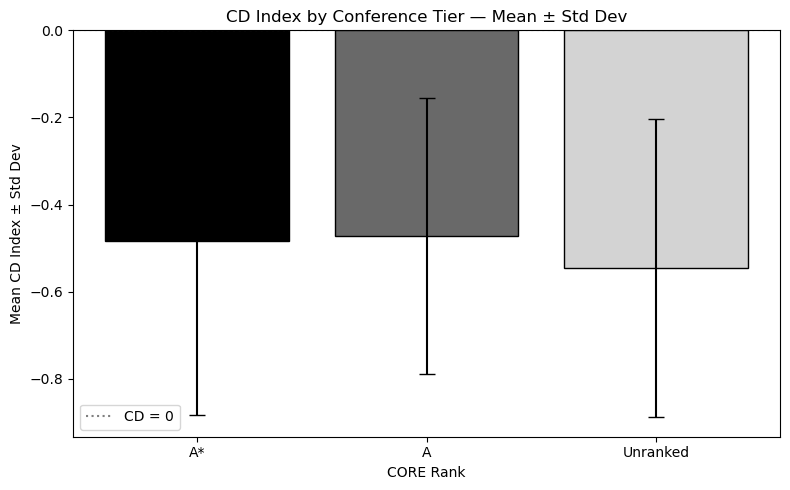

In [3]:
tier_stats = df_cd.groupby('core_rank')['cd_reliable'].agg(
    mean='mean', std='std', count='count'
).reset_index()
tier_stats['se'] = tier_stats['std'] / np.sqrt(tier_stats['count'])
tier_stats = tier_stats[tier_stats['core_rank'].isin(['A*','A','Unranked'])]
tier_stats['core_rank'] = pd.Categorical(tier_stats['core_rank'], ['A*','A','Unranked'])
tier_stats = tier_stats.sort_values('core_rank')

print(tier_stats)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(tier_stats))
bars = ax.bar(x, tier_stats['mean'], yerr=tier_stats['std'],
              color=['black','dimgray','lightgray'],
              edgecolor='black', capsize=6, error_kw=dict(ecolor='black', lw=1.5))
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, label='CD = 0')
ax.set_xticks(x)
ax.set_xticklabels(tier_stats['core_rank'])
ax.set_xlabel('CORE Rank')
ax.set_ylabel('Mean CD Index ± Std Dev')
ax.set_title('CD Index by Conference Tier — Mean ± Std Dev')
ax.legend()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(str(FIGURES / "21_cd_tier_std.png"), dpi=150, bbox_inches='tight')
plt.show()

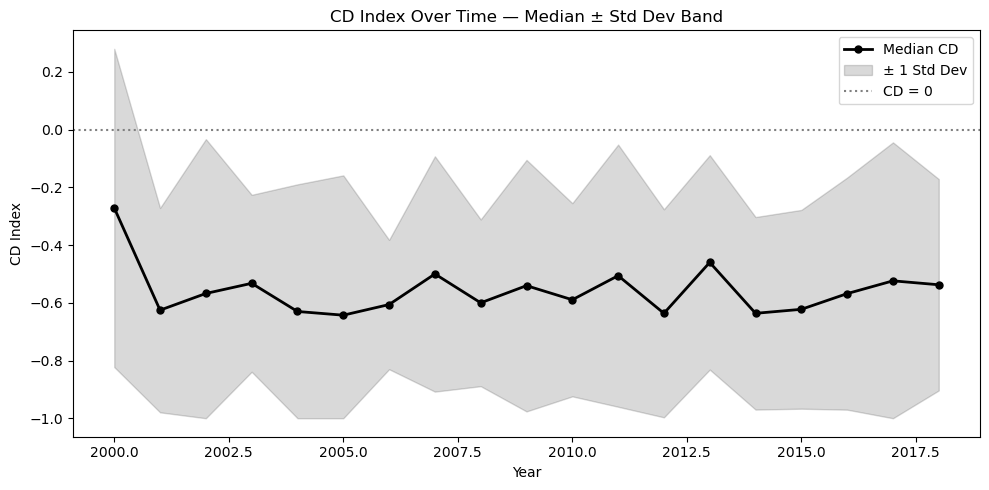

In [5]:
cd_time = df_cd.groupby('year')['cd_reliable'].agg(
    median='median', std='std', count='count'
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cd_time['year'], cd_time['median'], color='black', linewidth=2,
        marker='o', markersize=5, label='Median CD')
# Fix: clip std band to valid CD range
lower = (cd_time['median'] - cd_time['std']).clip(lower=-1)
upper = (cd_time['median'] + cd_time['std']).clip(upper=1)
ax.fill_between(cd_time['year'], lower, upper,
                alpha=0.15, color='black', label='± 1 Std Dev')
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, label='CD = 0')
ax.set_xlabel('Year')
ax.set_ylabel('CD Index')
ax.set_title('CD Index Over Time — Median ± Std Dev Band')
ax.legend()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(str(FIGURES / "21_cd_time_std.png"), dpi=150, bbox_inches='tight')
plt.show()